In [35]:
import numpy as np
import pandas as pd
from itertools import product
import time
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from pycellga.mutation.byte_mutation_random import ByteMutationRandom
from pycellga.recombination.byte_one_point_crossover import ByteOnePointCrossover
from pycellga.selection.tournament_selection import TournamentSelection
from pycellga.optimizer import graph_cga
from pycellga.GraphProblem import GraphRastriginProblem
import networkx as nx
from networkx import erdos_renyi_graph, grid_graph
from typing import Union
from pycellga.GraphProblem import GraphRosenbrockProblem, GraphAckleyProblem, GraphGriewankProblem

BOUNDARIES = 5

PROBLEM_TYPING = Union[
    GraphRastriginProblem,
    GraphRosenbrockProblem,
    GraphAckleyProblem,
    GraphGriewankProblem
]


def run_cga(dims, n_generations, n_rows, n_cols, problem):
    result = graph_cga(
        n_rows=n_rows,
        n_cols=n_cols,
        n_gen=n_generations,
        ch_size=dims,
        p_crossover=0.9,
        p_mutation=0.2,
        problem=problem,
        selection=TournamentSelection,
        recombination=ByteOnePointCrossover,
        mutation=ByteMutationRandom,
        seed_par=100,

    )
    return (result.chromosome, result.fitness_value)


def set_up_problem(n_rows, n_cols, dims, offset, problem_type: PROBLEM_TYPING) -> PROBLEM_TYPING: # type: ignore
    torus_graph = grid_graph(dim=(n_rows, n_cols), periodic=True)
    torus_graph_nodes_flattened = {node: i for i, node in enumerate(torus_graph.nodes)}
    empty_graph = nx.Graph()
    for edge in torus_graph.edges:
        empty_graph.add_edge(torus_graph_nodes_flattened[edge[0]], torus_graph_nodes_flattened[edge[1]])
    torus_graph = empty_graph

    #setting up random offset to see 
    return problem_type(n_var=dims, graph=torus_graph, offset=offset, boundaries=BOUNDARIES)


class CGAParameterStudy:
    def __init__(self):

        
        # Stałe parametry
        self.fixed_params = {
            'selection': TournamentSelection,
            'recombination': ByteOnePointCrossover,
            'mutation': ByteMutationRandom,
            'seed_par': 100,
        }
        
        self.results = []
    
    def run_single_experiment(self, params: Dict, problem_class, n_runs: int = 20) -> Dict:
        """Uruchamia pojedynczy eksperyment z wieloma powtórzeniami"""
        results = []
        times = []
        
        for run in range(n_runs):
            # Tworzymy problem z różnymi offsetami dla różnorodności
            offset = np.random.uniform(-1, 1, params['dimensions'])
            
            problem = set_up_problem(params['topology'][0], params['topology'][1], params['dimensions'], offset, problem_class)
            
            start_time = time.time()
            
            try:
            
                result  = graph_cga(
                ch_size=params['dimensions'],
                    n_gen=params['n_generations'],
                    n_rows=params['topology'][0],
                    n_cols=params['topology'][1],
                    problem=problem,
                    p_crossover=params['p_crossover'],
                    p_mutation=params['p_mutation'],
                    **self.fixed_params  )

                
                end_time = time.time()
                
                results.append(result.fitness_value)
                times.append(end_time - start_time)
                
            except Exception as e:
                print(f"Błąd w eksperymencie: {e}")
                # results.append(float('inf'))
                # times.append(0)
        
        return {
            'mean_fitness': np.mean(results),
            'std_fitness': np.std(results),
            'min_fitness': np.min(results),
            'max_fitness': np.max(results),
            'mean_time': np.mean(times),
            'success_rate': sum(1 for r in results if r < 1e-6) / len(results)  # Dla minimalizacji
        }
    
    def run_topology_study(self, problem_class, dims: int = 20, n_gen: int = 500, n_runs: int = 20):
        """Studium wpływu topologii na wydajność"""
        print("=== STUDIUM TOPOLOGII ===")
        
        topologies = [
            (5, 10, "5x10 (50)"),
            (7, 7, "7x7 (49)"),
            (10, 10, "10x10 (100)"),
            (8, 16, "8x16 (128)"),
            (16, 16, "16x16 (256)")
        ]
        
        results = []
        
        for n_rows, n_cols, desc in topologies:
            params = {
                'dimensions': dims,
                'n_generations': n_gen,
                'topology': (n_rows, n_cols),
                'p_crossover': 0.9,
                'p_mutation': 0.1
            }
            
            print(f"Testowanie topologii {desc}...")
            result = self.run_single_experiment(params, problem_class, n_runs=n_runs)
            result['topology'] = desc
            result['population_size'] = n_rows * n_cols
            results.append(result)
        
        return pd.DataFrame(results)
    
    def run_operator_study(self, problem_class, dims: int = 20, n_runs: int = 20):
        """Studium wpływu operatorów genetycznych"""
        print("=== STUDIUM OPERATORÓW ===")
        
        crossover_rates = [0.7, 0.8, 0.9, 1.0]
        mutation_rates = [0.01, 0.05, 0.1, 0.2]
        
        results = []
        
        for p_cross, p_mut in product(crossover_rates, mutation_rates):
            params = {
                'dimensions': dims,
                'n_generations': 1000,
                'topology': (10, 10),
                'p_crossover': p_cross,
                'p_mutation': p_mut
            }
            
            print(f"Testowanie p_cross={p_cross}, p_mut={p_mut}...")
            result = self.run_single_experiment(params, problem_class, n_runs=n_runs)
            result['p_crossover'] = p_cross
            result['p_mutation'] = p_mut
            results.append(result)
        
        return pd.DataFrame(results)
    

    
    def run_budget_study(self, problem_class, dims: int = 20, n_runs: int = 20):
        """Studium wpływu budżetu obliczeniowego"""
        print("=== STUDIUM BUDŻETU ===")
        
        budgets = [200, 300, 500, 1000]  # liczba generacji (zmniejszone)
        results = []
        
        for budget in budgets:
            params = {
                'dimensions': dims,
                'n_generations': budget,
                'topology': (10, 10),
                'p_crossover': 0.9,
                'p_mutation': 0.1
            }
            
            print(f"Testowanie budżetu {budget} generacji...")
            result = self.run_single_experiment(params, problem_class, n_runs=n_runs)
            result['budget'] = budget
            results.append(result)
        
        return pd.DataFrame(results)
    
    def visualize_results(self, df: pd.DataFrame, study_type: str):
        """Wizualizacja wyników studium"""
        plt.figure(figsize=(15, 10))
        
        if study_type == "topology":
            plt.subplot(2, 2, 1)
            plt.bar(df['topology'], df['mean_fitness'])

            plt.title('Średnia fitness vs Topologia')
            plt.xticks(rotation=45)
            
            plt.subplot(2, 2, 2)
            plt.scatter(df['population_size'], df['mean_fitness'])

            plt.xlabel('Rozmiar populacji')
            plt.ylabel('Średnia fitness')
            plt.title('Fitness vs Rozmiar populacji')
            
        elif study_type == "operators":
            pivot_mean = df.pivot(index='p_mutation', columns='p_crossover', values='mean_fitness')
            plt.subplot(2, 2, 1)
            sns.heatmap(pivot_mean, annot=True, fmt='.2e', cmap='viridis')
            plt.title('Średnia fitness')
            
            pivot_std = df.pivot(index='p_mutation', columns='p_crossover', values='std_fitness')
            plt.subplot(2, 2, 2)
            sns.heatmap(pivot_std, annot=True, fmt='.2e', cmap='plasma')
            plt.title('Odchylenie standardowe fitness')
            
            
        elif study_type == "budget":
            plt.subplot(2, 2, 1)
            plt.plot(df['budget'], df['mean_fitness'], 'o-')
            plt.xlabel('Liczba generacji')
            plt.ylabel('Średnia fitness')
            plt.title('Konwergencja vs Budżet')
        
        plt.tight_layout()
        plt.show()
    
    def run_full_study(self, problem_classes: List, output_file: str = "cga_study_results.xlsx"):
        """Uruchamia pełne studium parametryczne"""
        all_results = {}
        
        for prob_name, prob_class in problem_classes:
            print(f"\n{'='*50}")
            print(f"STUDIUM DLA FUNKCJI: {prob_name}")
            print(f"{'='*50}")
            
            results = {}
            
            # Poszczególne studia
            results['topology'] = self.run_topology_study(prob_class, dims=5, n_runs=20)
            results['operators'] = self.run_operator_study(prob_class, dims=5, n_runs=20)
            results['budget'] = self.run_budget_study(prob_class, dims=5, n_runs=20)
            
            all_results[prob_name] = results
            
            # # Wizualizacje
            # for study_type, df in results.items():
            #     print(f"\nWyniki studium {study_type}:")
            #     print(df.to_string())
            #     self.visualize_results(df, study_type)
        
        return all_results


study = CGAParameterStudy()

# Lista funkcji do testowania (tylko Rastrigin)
problem_classes = [
    ("Rastrigin", GraphRastriginProblem),
]


In [ ]:

# Uruchomienie pełnego studium
results = study.run_full_study(problem_classes)


Wyniki studium topology:
   mean_fitness  std_fitness  min_fitness  max_fitness  mean_time  success_rate     topology  population_size
0  -1677.058543   411.387261 -2319.111067  -966.791202   0.623364           1.0    5x10 (50)               50
1  -1679.890612   444.952129 -2352.360615  -612.674970   0.598366           1.0     7x7 (49)               49
2  -2021.837757   218.793443 -2338.859912 -1589.241546   1.599627           1.0  10x10 (100)              100
3  -2104.815284   124.697871 -2282.558629 -1912.581035   2.025622           1.0   8x16 (128)              128
4  -2235.000093    74.051350 -2339.718388 -2181.659765   4.835037           1.0  16x16 (256)              256


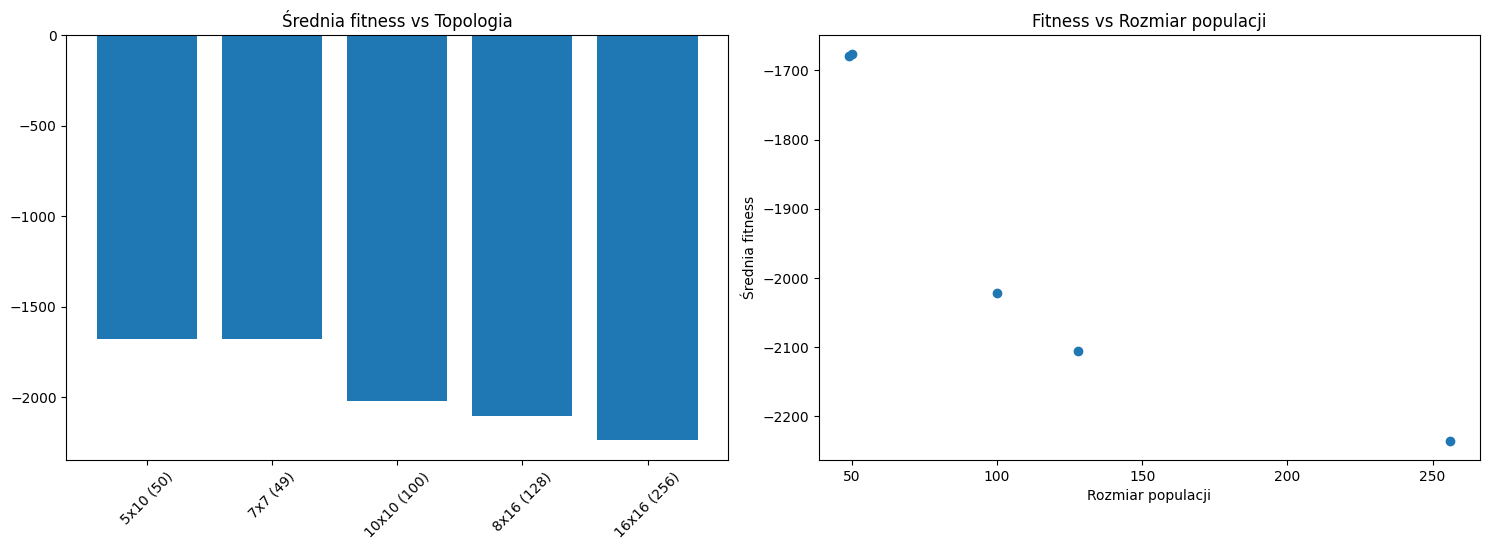


Wyniki studium operators:
    mean_fitness  std_fitness  min_fitness  max_fitness  mean_time  success_rate  p_crossover  p_mutation
0   -1836.244697   279.824807 -2316.734264 -1288.963638   2.424829           1.0          0.7        0.01
1   -2071.129116   186.851285 -2433.773343 -1863.901114   2.526678           1.0          0.7        0.05
2   -2139.949840   418.395105 -2494.227662  -921.988647   2.517790           1.0          0.7        0.10
3   -2124.835352   268.417864 -2405.669698 -1726.469668   2.665354           1.0          0.7        0.20
4   -2034.601440   207.253751 -2364.991006 -1768.720628   2.694243           1.0          0.8        0.01
5   -2098.288651   355.626211 -2414.090803 -1140.849868   2.654549           1.0          0.8        0.05
6   -2012.567658   234.585129 -2303.898846 -1665.922043   2.777134           1.0          0.8        0.10
7   -2075.697464   129.011616 -2238.564571 -1799.943286   3.067707           1.0          0.8        0.20
8   -1911.028814   

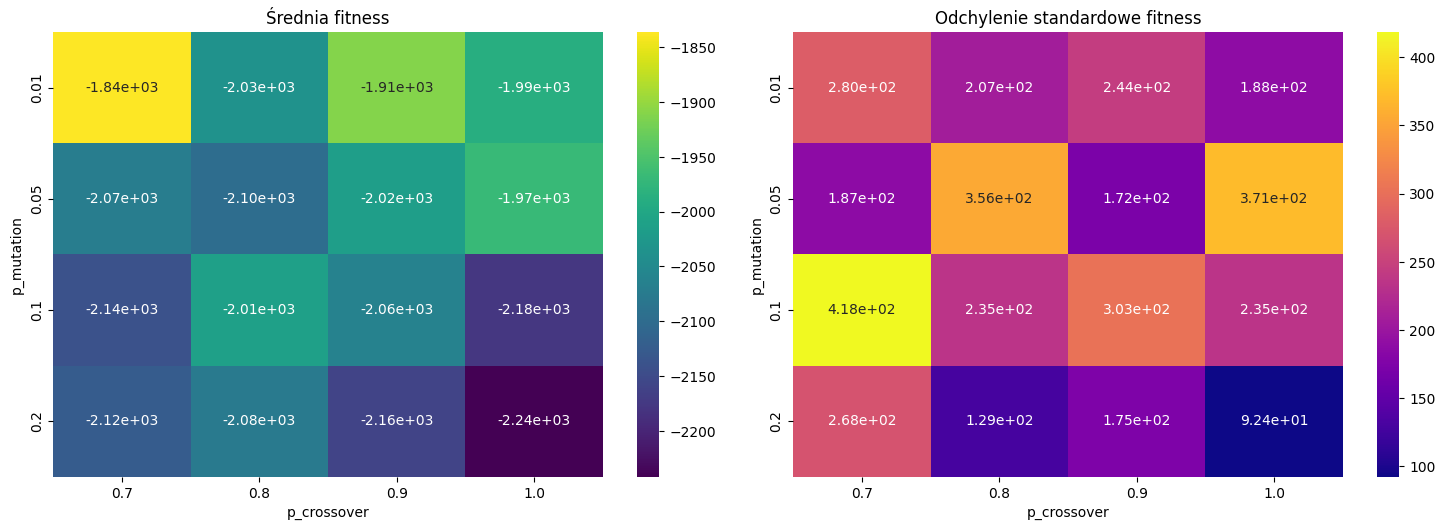


Wyniki studium budget:
   mean_fitness  std_fitness  min_fitness  max_fitness  mean_time  success_rate  budget
0  -1961.305636   312.723395 -2253.600852 -1258.509143   0.635549           1.0     200
1  -1936.076990   324.237896 -2331.391791 -1144.480836   0.960259           1.0     300
2  -1983.452207   213.544211 -2276.982138 -1497.069293   1.606203           1.0     500
3  -2091.580381   221.299113 -2382.139894 -1681.613210   3.129784           1.0    1000


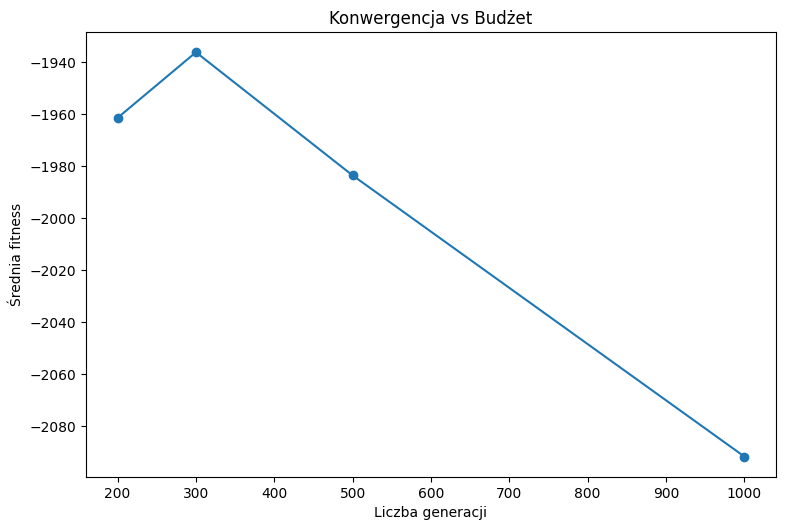

In [36]:
# Wizualizacje
for study_type, df in results['Rastrigin'].items():
    print(f"\nWyniki studium {study_type}:")
    print(df.to_string())
    study.visualize_results(df, study_type)

In [26]:
results

{'Rastrigin': {'topology':    mean_fitness  std_fitness  min_fitness  max_fitness  mean_time  \
  0  -1677.058543   411.387261 -2319.111067  -966.791202   0.623364   
  1  -1679.890612   444.952129 -2352.360615  -612.674970   0.598366   
  2  -2021.837757   218.793443 -2338.859912 -1589.241546   1.599627   
  3  -2104.815284   124.697871 -2282.558629 -1912.581035   2.025622   
  4  -2235.000093    74.051350 -2339.718388 -2181.659765   4.835037   
  
     success_rate     topology  population_size  
  0           1.0    5x10 (50)               50  
  1           1.0     7x7 (49)               49  
  2           1.0  10x10 (100)              100  
  3           1.0   8x16 (128)              128  
  4           1.0  16x16 (256)              256  ,
  'operators':     mean_fitness  std_fitness  min_fitness  max_fitness  mean_time  \
  0   -1836.244697   279.824807 -2316.734264 -1288.963638   2.424829   
  1   -2071.129116   186.851285 -2433.773343 -1863.901114   2.526678   
  2   -2139.9498